In [3]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, Any, List

import numpy as np
import pandas as pd

def safe_read_csv(path: Path) -> pd.DataFrame:
    """Read CSV with a couple of safe fallbacks."""
    try:
        return pd.read_csv(path)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="latin-1")


def summarize_df(df: pd.DataFrame) -> Dict[str, Any]:
    n_rows, n_cols = df.shape

    # missing
    missing_count = df.isna().sum()
    missing_pct = (missing_count / max(n_rows, 1) * 100).round(2)

    missing_table = (
        pd.DataFrame({"missing_count": missing_count, "missing_pct": missing_pct})
        .sort_values(["missing_count", "missing_pct"], ascending=False)
    )

    # duplicates
    dup_rows = int(df.duplicated().sum())

    # dtypes
    dtype_table = (
        pd.DataFrame({"dtype": df.dtypes.astype(str)})
        .reset_index()
        .rename(columns={"index": "column"})
    )

    # stats
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in df.columns if c not in numeric_cols]

    numeric_desc = df[numeric_cols].describe().T if numeric_cols else pd.DataFrame()
    categorical_desc = df[cat_cols].describe().T if cat_cols else pd.DataFrame()

    # unique counts
    nunique = df.nunique(dropna=True).sort_values(ascending=False)
    nunique_table = pd.DataFrame({"nunique": nunique}).reset_index().rename(columns={"index": "column"})

    return {
        "shape": (n_rows, n_cols),
        "dup_rows": dup_rows,
        "missing_table": missing_table,
        "dtype_table": dtype_table,
        "nunique_table": nunique_table,
        "numeric_desc": numeric_desc,
        "categorical_desc": categorical_desc,
        "numeric_cols": numeric_cols,
        "cat_cols": cat_cols,
    }


def print_header(title: str) -> None:
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


def ensure_outdir(outdir: Path) -> None:
    outdir.mkdir(parents=True, exist_ok=True)


def save_reports(summary: Dict[str, Any], dataset_name: str, outdir: Path) -> None:
    ensure_outdir(outdir)

    summary["missing_table"].to_csv(outdir / f"{dataset_name}__missing.csv")
    summary["dtype_table"].to_csv(outdir / f"{dataset_name}__dtypes.csv", index=False)
    summary["nunique_table"].to_csv(outdir / f"{dataset_name}__nunique.csv", index=False)

    if not summary["numeric_desc"].empty:
        summary["numeric_desc"].to_csv(outdir / f"{dataset_name}__numeric_desc.csv")
    if not summary["categorical_desc"].empty:
        summary["categorical_desc"].to_csv(outdir / f"{dataset_name}__categorical_desc.csv")

    report_path = outdir / f"{dataset_name}__report.txt"
    with report_path.open("w", encoding="utf-8") as f:
        n_rows, n_cols = summary["shape"]
        f.write(f"Dataset: {dataset_name}\n")
        f.write(f"Shape: {n_rows} rows x {n_cols} cols\n")
        f.write(f"Duplicate rows: {summary['dup_rows']}\n\n")

        f.write("=== Dtypes ===\n")
        f.write(summary["dtype_table"].to_string(index=False))
        f.write("\n\n=== Unique counts (top) ===\n")
        f.write(summary["nunique_table"].head(50).to_string(index=False))
        f.write("\n\n=== Missing values (sorted) ===\n")
        f.write(summary["missing_table"].head(100).to_string())
        f.write("\n")

        if not summary["numeric_desc"].empty:
            f.write("\n=== Numeric describe ===\n")
            f.write(summary["numeric_desc"].to_string())
            f.write("\n")

        if not summary["categorical_desc"].empty:
            f.write("\n=== Categorical describe ===\n")
            f.write(summary["categorical_desc"].to_string())
            f.write("\n")


In [4]:
# ✅ Edit this if needed
DATASETS = [
    "student_combined_data.csv",
    "student_performance_data.csv",
    "student_aptitude_data.csv",
]

SAVE_REPORTS = True
OUTDIR = "outputs"


In [5]:
outdir_path = Path(OUTDIR)

for p in DATASETS:
    path = Path(p)

    if not path.exists():
        print_header(f"[SKIP] File not found: {p}")
        continue

    dataset_name = path.stem
    print_header(f"DATASET: {path.name}")

    df = safe_read_csv(path)

    print("Preview (first 5 rows):")
    display(df.head(5))

    summary = summarize_df(df)

    # 1) jumlah data
    n_rows, n_cols = summary["shape"]
    print_header("1) JUMLAH DATA")
    print(f"Rows: {n_rows}")
    print(f"Columns: {n_cols}")

    # 2) karakteristik data
    print_header("2) KARAKTERISTIK DATA")
    print(f"Numeric cols ({len(summary['numeric_cols'])}): {summary['numeric_cols']}")
    print(f"Categorical/other cols ({len(summary['cat_cols'])}): {summary['cat_cols']}")

    print("\nDtypes:")
    display(summary["dtype_table"])

    print("\nUnique counts per column (top 30):")
    display(summary["nunique_table"].head(30))

    # 3) missing values
    print_header("3) MISSING VALUES")
    missing_nonzero = summary["missing_table"][summary["missing_table"]["missing_count"] > 0]
    if missing_nonzero.empty:
        print("No missing values found ✅")
    else:
        print("Columns with missing values (top 50):")
        display(missing_nonzero.head(50))

    # 4) duplicates
    print_header("4) DUPLICATE ROWS")
    print(f"Duplicate rows: {summary['dup_rows']}")

    # 5) basic stats
    print_header("5) RINGKASAN STATISTIK")
    if summary["numeric_desc"].empty:
        print("No numeric columns detected.")
    else:
        print("Numeric describe:")
        display(summary["numeric_desc"])

    if summary["categorical_desc"].empty:
        print("No categorical/object columns detected.")
    else:
        print("\nCategorical describe:")
        display(summary["categorical_desc"].head(30))

    # save outputs
    if SAVE_REPORTS:
        print_header("SAVING REPORTS")
        save_reports(summary, dataset_name, outdir_path)
        print(f"Saved to: {outdir_path.resolve()}")

print("\nDone.")



DATASET: student_combined_data.csv
Preview (first 5 rows):


,student_id,course_level,performance_score,aptitude_score
0,1,Advanced,3.70,72
1,2,Advanced,3.65,90
2,3,Advanced,3.55,68
3,4,Advanced,3.45,84
4,5,Advanced,3.55,72



1) JUMLAH DATA
Rows: 150
Columns: 4

2) KARAKTERISTIK DATA
Numeric cols (3): ['student_id', 'performance_score', 'aptitude_score']
Categorical/other cols (1): ['course_level']

Dtypes:


,column,dtype
0,student_id,int64
1,course_level,object
2,performance_score,float64
3,aptitude_score,int64



Unique counts per column (top 30):


...


3) MISSING VALUES
No missing values found ✅

4) DUPLICATE ROWS
Duplicate rows: 0

5) RINGKASAN STATISTIK
Numeric describe:


,count,mean,std,min,25%,50%,75%,max
student_id,150.0,75.50,43.445368,1.0,38.25,75.5,112.75,150.0
aptitude_score,150.0,44.24,24.228133,9.0,22.00,38.0,65.00,97.0



Categorical describe:


,count,unique,top,freq
course_level,150,3,Advanced,50



SAVING REPORTS
Saved to: C:\Users\Lenovo\Documents\DE\project2\outputs

Done.



=== DATA PREVIEW ===
   student_id course_level  performance_score  aptitude_score
0           1     Advanced               3.70              72
1           2     Advanced               3.65              90
2           3     Advanced               3.55              68
3           4     Advanced               3.45              84
4           5     Advanced               3.55              72

=== DESCRIPTIVE STATISTICS (NUMERICAL) ===
       performance_score  aptitude_score
count         150.000000      150.000000
mean            2.540667       44.240000
std             0.652830       24.228133
min             1.550000        9.000000
25%             1.950000       22.000000
50%             2.475000       38.000000
75%             3.037500       65.000000
max             3.800000       97.000000

Additional statistics:

performance_score
Skewness : 0.3530997784579576
Kurtosis : -1.141992121703979

aptitude_score
Skewness : 0.5831035448315905
Kurtosis : -0.8717044609481173

=== DESCRIPT

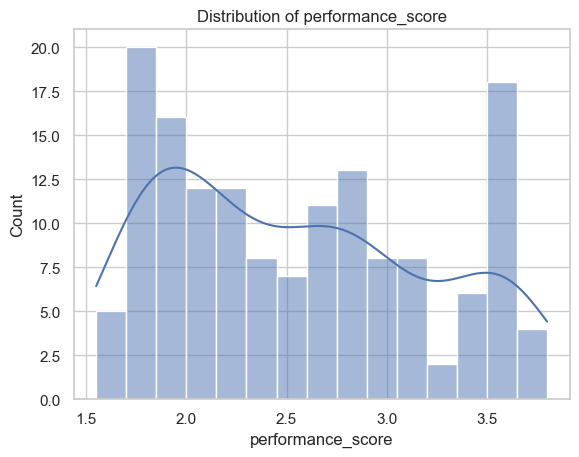

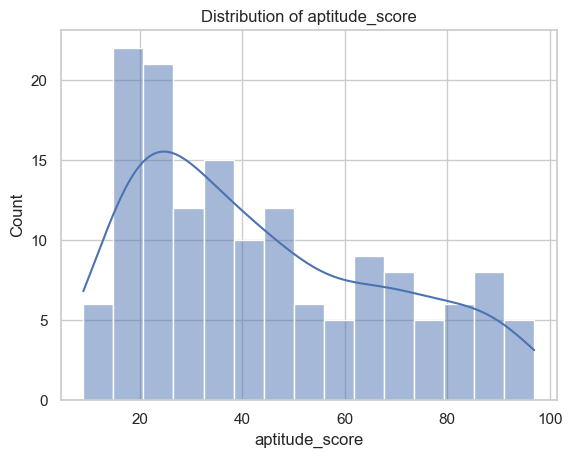

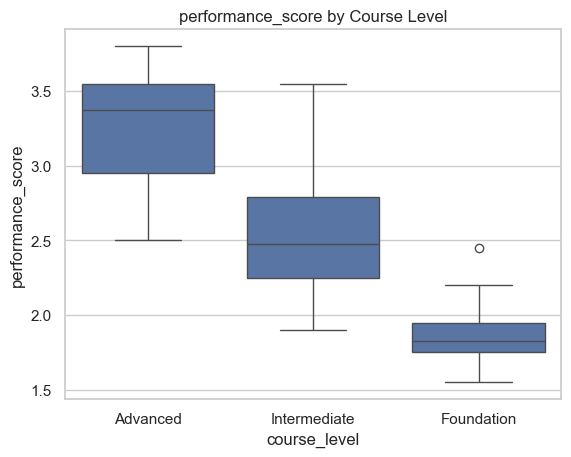

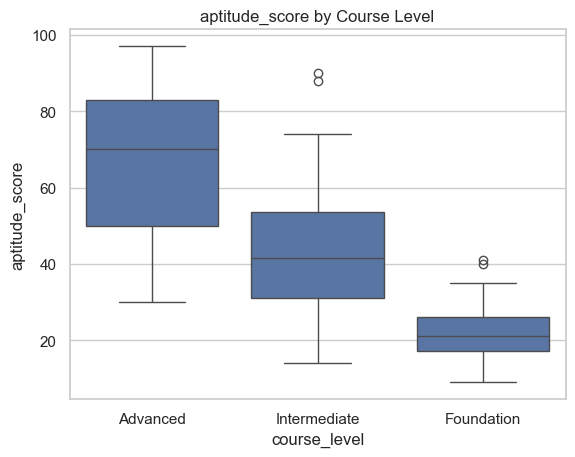


Descriptive statistics completed.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

# =====================
# 1. Load Data
# =====================
df = pd.read_csv("student_combined_data.csv")

print("\n=== DATA PREVIEW ===")
print(df.head())

# =====================
# 2. Descriptive Statistics (Numerical)
# =====================
print("\n=== DESCRIPTIVE STATISTICS (NUMERICAL) ===")
numerical_cols = ["performance_score", "aptitude_score"]
print(df[numerical_cols].describe())

# Tambahan statistik
print("\nAdditional statistics:")
for col in numerical_cols:
    print(f"\n{col}")
    print("Skewness :", df[col].skew())
    print("Kurtosis :", df[col].kurtosis())

# =====================
# 3. Descriptive Statistics (Categorical)
# =====================
print("\n=== DESCRIPTIVE STATISTICS (CATEGORICAL) ===")
print(df["course_level"].value_counts())
print(df["course_level"].value_counts(normalize=True) * 100)

# =====================
# 4. Grouped Statistics
# =====================
print("\n=== GROUPED STATISTICS BY COURSE LEVEL ===")
grouped_stats = df.groupby("course_level")[numerical_cols].agg(
    ["mean", "median", "std", "min", "max"]
)
print(grouped_stats)

# =====================
# 5. Visualizations
# =====================
sns.set(style="whitegrid")

# Histogram
for col in numerical_cols:
    plt.figure()
    sns.histplot(df[col], bins=15, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# Boxplot by course level
for col in numerical_cols:
    plt.figure()
    sns.boxplot(x="course_level", y=col, data=df)
    plt.title(f"{col} by Course Level")
    plt.show()

print("\nDescriptive statistics completed.")

# Final Notebook — Chapters 4–8 (Combined)
This notebook consolidates **Chapter 4–8** into one runnable workflow:

- **Chapter 4:** Data overview + quality assurance + software  
- **Chapter 5:** Assumption tests + One-Way ANOVA (plus Welch check) + effect sizes  
- **Chapter 6:** Post-hoc Tukey HSD  
- **Chapter 7:** Correlation analysis (overall + by level)  
- **Chapter 8:** Practical interpretation (η²/ω², Cohen’s d, r/r²)

> **Navigation:** Use the **Outline / Table of Contents** panel in VS Code / Jupyter.  
> The headings below will appear automatically.


# Chapter 4 — About the Study: Data, QA, and Software
## 4.1 The Data: What We Examined
## 4.2 How We Analyzed the Data
## 4.3 Analysis Software


In [7]:

# =====================
# 4.0 Imports + helpers
# =====================
from __future__ import annotations

import sys, platform
from pathlib import Path
from typing import Dict, Any

import numpy as np
import pandas as pd
from IPython.display import display, Markdown

def md(text: str):
    display(Markdown(text))

def normalize_course_level(s: pd.Series) -> pd.Series:
    return (
        s.astype(str)
         .str.strip()
         .str.lower()
         .replace({"adv":"advanced"})
         .str.title()
    )

LEVEL_ORDER = ["Foundation", "Intermediate", "Advanced"]


In [8]:

# =====================
# 4.1 Load dataset
# Supports:
# - student_combined_data.csv
# - OR merge performance + aptitude if provided
# =====================
COMBINED_PATH = Path("student_combined_data.csv")
PERFORMANCE_PATH = Path("student_performance_data.csv")
APTITUDE_PATH    = Path("student_aptitude_data.csv")

COL_ALIASES = {
    "student_id": ["student_id", "id", "studentid"],
    "course_level": ["course_level", "level", "course", "placement_level"],
    "performance_score": ["performance_score", "performance", "final_score", "grade"],
    "aptitude_score": ["aptitude_score", "aptitude", "apt_score"],
}

def pick_col(df: pd.DataFrame, wanted: str) -> str:
    candidates = COL_ALIASES[wanted]
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    raise KeyError(f"Cannot find a column for '{wanted}'. Tried: {candidates}. Found: {list(df.columns)}")

def safe_read_csv(path: Path) -> pd.DataFrame:
    try:
        return pd.read_csv(path)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="latin-1")

def load_dataset() -> pd.DataFrame:
    if COMBINED_PATH.exists():
        df0 = safe_read_csv(COMBINED_PATH)
        rename_map = {
            pick_col(df0, "student_id"): "student_id",
            pick_col(df0, "course_level"): "course_level",
            pick_col(df0, "performance_score"): "performance_score",
            pick_col(df0, "aptitude_score"): "aptitude_score",
        }
        return df0.rename(columns=rename_map)

    if PERFORMANCE_PATH.exists() and APTITUDE_PATH.exists():
        perf = safe_read_csv(PERFORMANCE_PATH)
        apt  = safe_read_csv(APTITUDE_PATH)

        perf = perf.rename(columns={
            pick_col(perf, "student_id"): "student_id",
            pick_col(perf, "course_level"): "course_level",
            pick_col(perf, "performance_score"): "performance_score",
        })
        apt = apt.rename(columns={
            pick_col(apt, "student_id"): "student_id",
            pick_col(apt, "course_level"): "course_level",
            pick_col(apt, "aptitude_score"): "aptitude_score",
        })

        df0 = perf.merge(apt[["student_id","aptitude_score"]], on="student_id", how="inner")
        return df0

    raise FileNotFoundError(
        "Could not find student_combined_data.csv OR both student_performance_data.csv + student_aptitude_data.csv"
    )

df = load_dataset()

df["course_level"] = normalize_course_level(df["course_level"])
df["performance_score"] = pd.to_numeric(df["performance_score"], errors="coerce")
df["aptitude_score"] = pd.to_numeric(df["aptitude_score"], errors="coerce")

df = df[df["course_level"].isin(LEVEL_ORDER)].copy()
df["course_level"] = pd.Categorical(df["course_level"], categories=LEVEL_ORDER, ordered=True)

md("### Loaded dataset preview")
display(df.head())
md(f"**Shape:** {df.shape[0]} rows × {df.shape[1]} columns")


### Loaded dataset preview

,student_id,course_level,performance_score,aptitude_score
0,1,Advanced,3.70,72
1,2,Advanced,3.65,90
2,3,Advanced,3.55,68
3,4,Advanced,3.45,84
4,5,Advanced,3.55,72


**Shape:** 150 rows × 4 columns

In [9]:

# =====================
# 4.1.1 Sample size and distribution
# =====================
md("## 4.1.1 Who Was Included")

n_total = len(df)
level_counts = df["course_level"].value_counts().reindex(LEVEL_ORDER)

md(f"**Sample Size:** {n_total} students total")
display(level_counts.to_frame("count"))

md("### Stratified Random Sampling Check (expected 50 per level)")
if (level_counts == 50).all():
    md("✅ Distribution matches: **50 students per level**")
else:
    md("⚠️ Distribution does **not** match 50 each. Please verify dataset selection / filtering.")


## 4.1.1 Who Was Included

**Sample Size:** 150 students total

,count
course_level,
Foundation,50
Intermediate,50
Advanced,50


### Stratified Random Sampling Check (expected 50 per level)

✅ Distribution matches: **50 students per level**

In [10]:

# =====================
# 4.1.2 What we measured (ranges)
# =====================
md("## 4.1.2 What We Measured")

apt_min, apt_max = df["aptitude_score"].min(), df["aptitude_score"].max()
perf_min, perf_max = df["performance_score"].min(), df["performance_score"].max()

md(
    f"### Aptitude Score\n"
    f"- **Theoretical range:** 0–126  \n"
    f"- **Actual range (dataset):** **{apt_min:.2f}** to **{apt_max:.2f}**\n\n"
    f"### Performance Score\n"
    f"- **Theoretical range:** 0–4.0  \n"
    f"- **Actual range (dataset):** **{perf_min:.2f}** to **{perf_max:.2f}**"
)


## 4.1.2 What We Measured

### Aptitude Score
- **Theoretical range:** 0–126  
- **Actual range (dataset):** **9.00** to **97.00**

### Performance Score
- **Theoretical range:** 0–4.0  
- **Actual range (dataset):** **1.55** to **3.80**

In [11]:

# =====================
# 4.2 Data Quality (QA)
# =====================
md("## 4.2 Data Quality (Quality Assurance)")

required = ["student_id","course_level","performance_score","aptitude_score"]
missing = df[required].isna().sum()
missing_total = int(missing.sum())

dup_id = int(df["student_id"].duplicated().sum())
dup_rows = int(df.duplicated().sum())

apt_out = df[(df["aptitude_score"] < 0) | (df["aptitude_score"] > 126)]
perf_out = df[(df["performance_score"] < 0) | (df["performance_score"] > 4.0)]

md("### Completeness (Missing Values)")
display(missing.to_frame("missing_count"))
md("✅ No missing values found." if missing_total == 0 else f"⚠️ Missing values detected: {missing_total}")

md("### Duplicates")
md(f"- Duplicate **student_id**: **{dup_id}**  \n- Duplicate **rows**: **{dup_rows}**")
if dup_id == 0 and dup_rows == 0:
    md("✅ No duplicates detected.")
else:
    md("⚠️ Duplicates detected — consider deduplication before analysis.")

md("### Range Validity Checks")
md(f"- Aptitude outside 0–126: **{len(apt_out)}** rows  \n- Performance outside 0–4.0: **{len(perf_out)}** rows")
if len(apt_out)==0 and len(perf_out)==0:
    md("✅ All scores fall within expected theoretical ranges.")
else:
    md("⚠️ Out-of-range samples:")
    if len(apt_out)>0: display(apt_out.head(10))
    if len(perf_out)>0: display(perf_out.head(10))

md("### Confidentiality / Anonymization Check")
suspicious_keywords = ["name", "email", "phone", "address", "dob"]
suspicious_cols = [c for c in df.columns if any(k in c.lower() for k in suspicious_keywords)]
md("✅ No obvious personal-identifying columns detected (IDs only)." if not suspicious_cols
   else f"⚠️ Potentially identifying columns found: **{suspicious_cols}**")


## 4.2 Data Quality (Quality Assurance)

### Completeness (Missing Values)

,missing_count
student_id,0
course_level,0
performance_score,0
aptitude_score,0


✅ No missing values found.

### Duplicates

...

### Range Validity Checks

- Aptitude outside 0–126: **0** rows  
- Performance outside 0–4.0: **0** rows

✅ All scores fall within expected theoretical ranges.

### Confidentiality / Anonymization Check

✅ No obvious personal-identifying columns detected (IDs only).

In [12]:

# =====================
# 4.3 Analysis Software
# =====================
md("## 4.3 Analysis Software")

versions = pd.DataFrame({
    "component": ["python", "platform", "pandas", "numpy"],
    "version": [sys.version.split()[0], platform.platform(), pd.__version__, np.__version__]
})
display(versions)


## 4.3 Analysis Software

,component,version
0,python,3.12.10
1,platform,Windows-11-10.0.26200-SP0
2,pandas,2.3.3
3,numpy,2.3.0


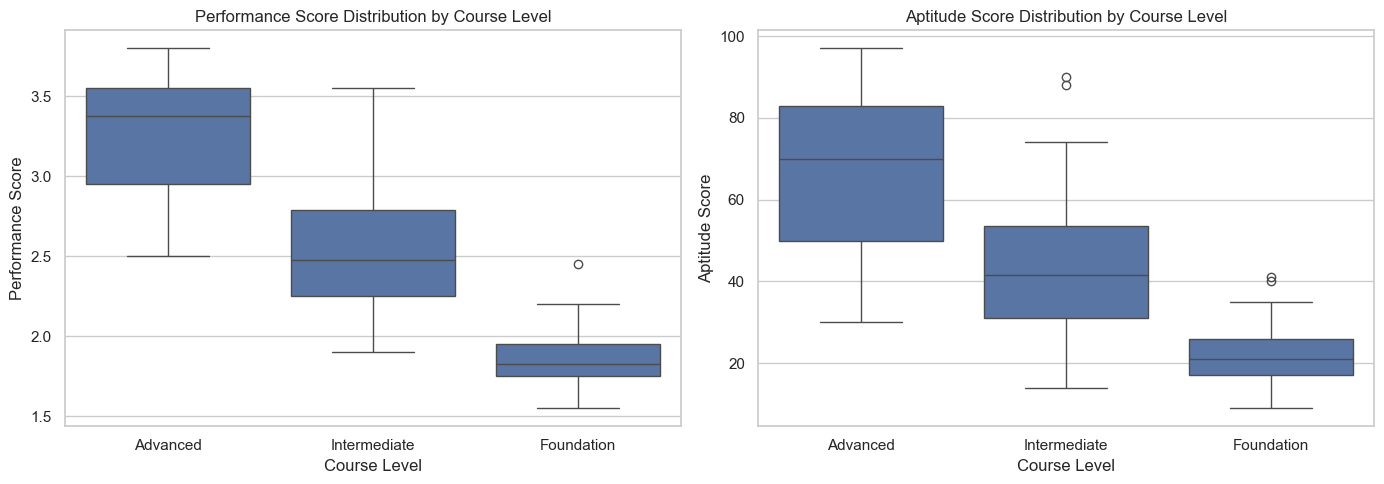

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")
LEVEL_ORDER = ["Advanced", "Intermediate", "Foundation"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df,
    x="course_level",
    y="performance_score",
    order=LEVEL_ORDER,
    ax=axes[0]
)
axes[0].set_title("Performance Score Distribution by Course Level")
axes[0].set_xlabel("Course Level")
axes[0].set_ylabel("Performance Score")

sns.boxplot(
    data=df,
    x="course_level",
    y="aptitude_score",
    order=LEVEL_ORDER,
    ax=axes[1]
)
axes[1].set_title("Aptitude Score Distribution by Course Level")
axes[1].set_xlabel("Course Level")
axes[1].set_ylabel("Aptitude Score")

plt.tight_layout()
plt.show()


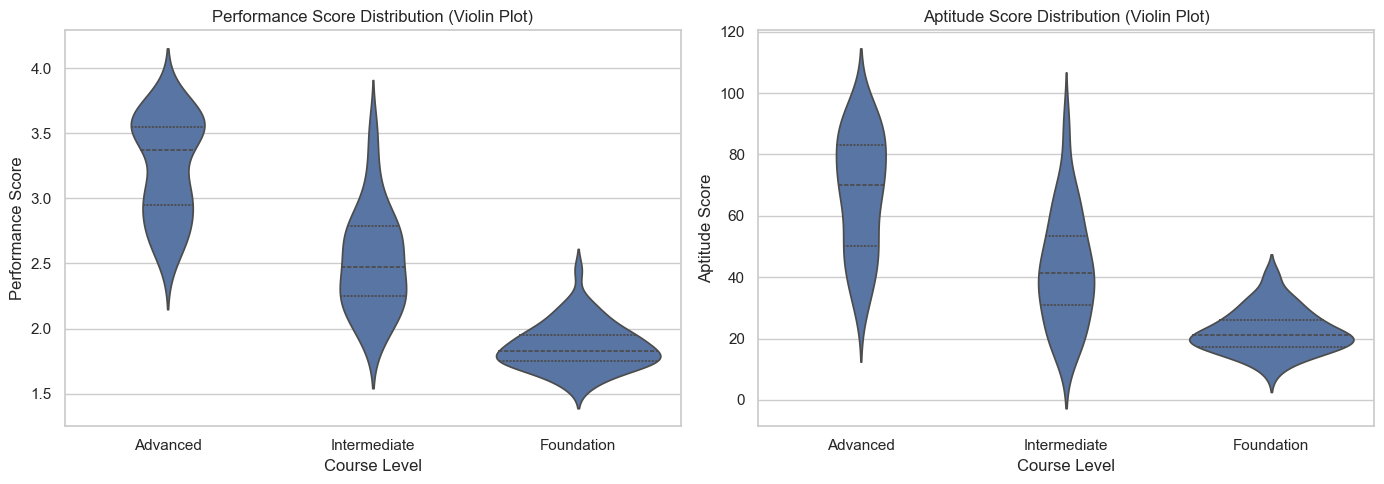

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(
    data=df,
    x="course_level",
    y="performance_score",
    order=LEVEL_ORDER,
    inner="quartile",
    ax=axes[0]
)
axes[0].set_title("Performance Score Distribution (Violin Plot)")
axes[0].set_xlabel("Course Level")
axes[0].set_ylabel("Performance Score")

sns.violinplot(
    data=df,
    x="course_level",
    y="aptitude_score",
    order=LEVEL_ORDER,
    inner="quartile",
    ax=axes[1]
)
axes[1].set_title("Aptitude Score Distribution (Violin Plot)")
axes[1].set_xlabel("Course Level")
axes[1].set_ylabel("Aptitude Score")

plt.tight_layout()
plt.show()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_1184\3761239907.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("course_level")


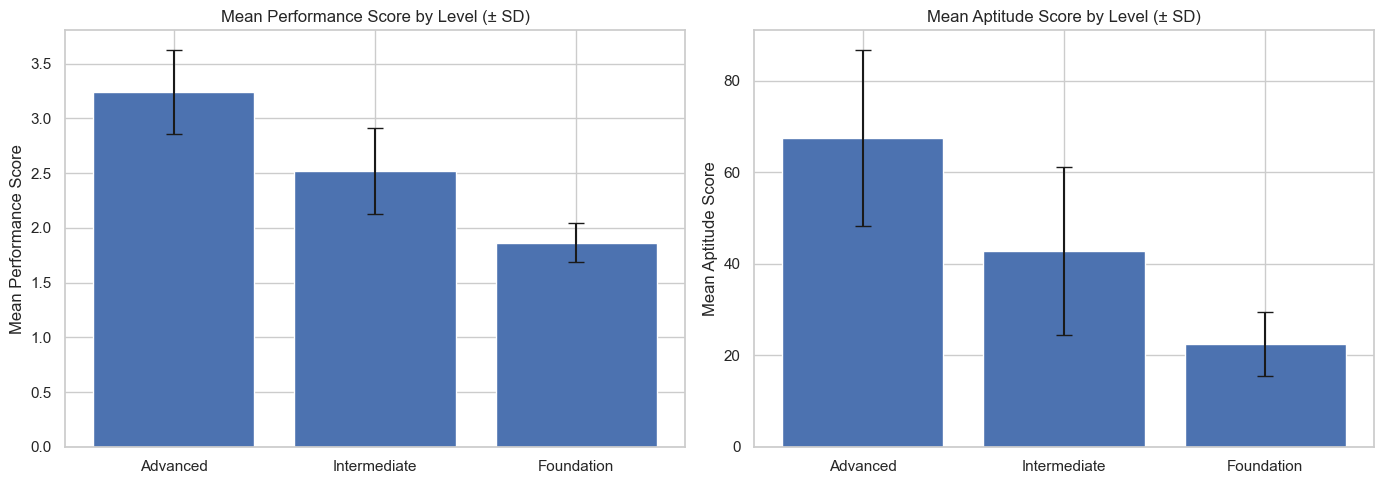

In [15]:
summary = (
    df.groupby("course_level")
      .agg(
          mean_perf=("performance_score", "mean"),
          sd_perf=("performance_score", "std"),
          mean_apt=("aptitude_score", "mean"),
          sd_apt=("aptitude_score", "std"),
      )
      .reindex(LEVEL_ORDER)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    summary.index,
    summary["mean_perf"],
    yerr=summary["sd_perf"],
    capsize=6
)
axes[0].set_title("Mean Performance Score by Level (± SD)")
axes[0].set_ylabel("Mean Performance Score")

axes[1].bar(
    summary.index,
    summary["mean_apt"],
    yerr=summary["sd_apt"],
    capsize=6
)
axes[1].set_title("Mean Aptitude Score by Level (± SD)")
axes[1].set_ylabel("Mean Aptitude Score")

plt.tight_layout()
plt.show()


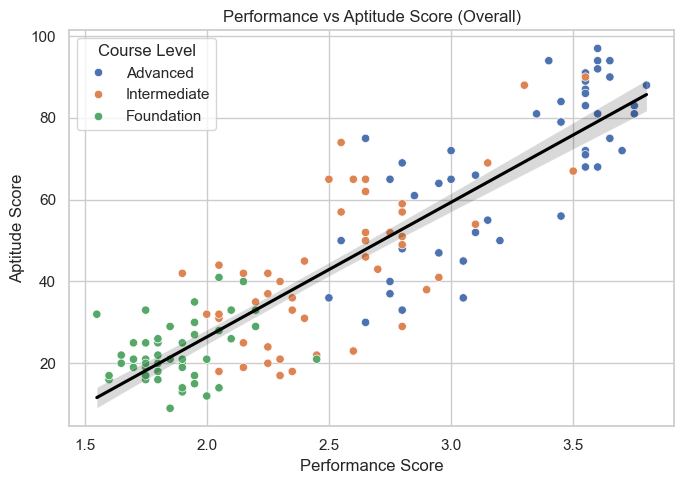

In [16]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="performance_score",
    y="aptitude_score",
    hue="course_level",
    hue_order=LEVEL_ORDER
)

sns.regplot(
    data=df,
    x="performance_score",
    y="aptitude_score",
    scatter=False,
    color="black"
)

plt.title("Performance vs Aptitude Score (Overall)")
plt.xlabel("Performance Score")
plt.ylabel("Aptitude Score")
plt.legend(title="Course Level")
plt.tight_layout()
plt.show()


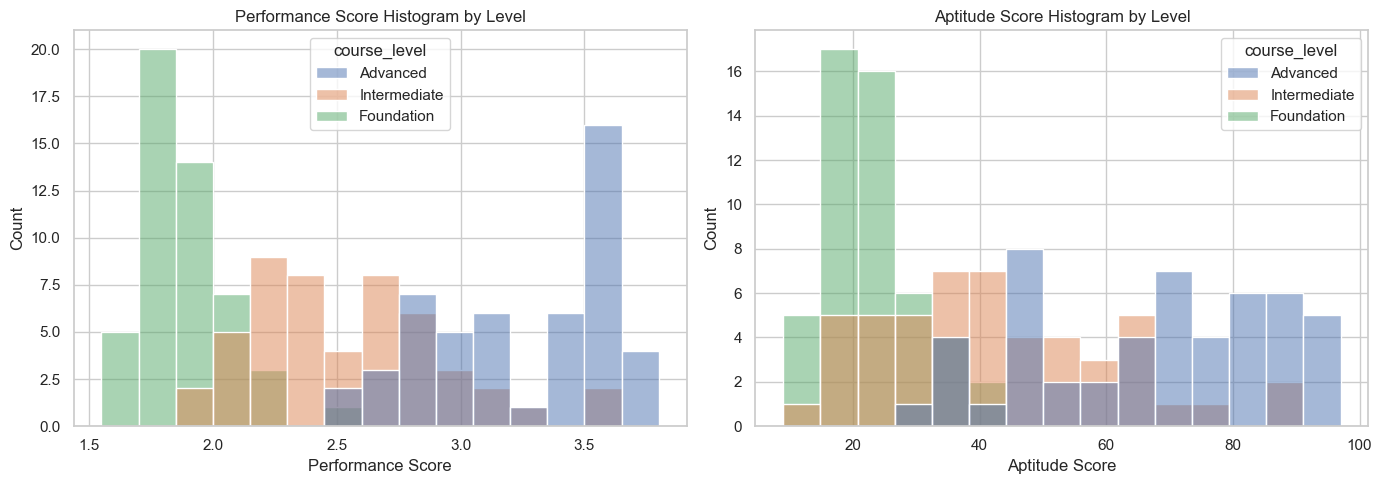

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df,
    x="performance_score",
    hue="course_level",
    hue_order=LEVEL_ORDER,
    bins=15,
    multiple="layer",
    ax=axes[0]
)
axes[0].set_title("Performance Score Histogram by Level")
axes[0].set_xlabel("Performance Score")

sns.histplot(
    data=df,
    x="aptitude_score",
    hue="course_level",
    hue_order=LEVEL_ORDER,
    bins=15,
    multiple="layer",
    ax=axes[1]
)
axes[1].set_title("Aptitude Score Histogram by Level")
axes[1].set_xlabel("Aptitude Score")

plt.tight_layout()
plt.show()


# Chapter 5 — Assumptions and One-Way ANOVA
## 5.1 Assumption Tests
## 5.2 One-Way ANOVA
## 5.3 Effect Sizes (η² and ω²)

# Chapter 6 — Post-Hoc Analysis (Tukey HSD)
## 6.1 Tukey HSD Pairwise Comparisons
## 6.2 Post-Hoc Interpretation Summary


In [18]:

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.stats.oneway as oneway


In [19]:

md("## 5.1 Assumption Tests (Normality & Homogeneity)")

def shapiro_by_group(data: pd.DataFrame, group_col: str, value_col: str, levels: list) -> pd.DataFrame:
    rows = []
    for lvl in levels:
        x = data.loc[data[group_col] == lvl, value_col].dropna()
        if len(x) < 3:
            rows.append({"course_level": lvl, "n": len(x), "W": np.nan, "p_value": np.nan, "note": "n<3"})
            continue
        try:
            W, p = stats.shapiro(x)
            note = ""
        except Exception as e:
            W, p = np.nan, np.nan
            note = str(e)
        rows.append({"course_level": lvl, "n": len(x), "W": W, "p_value": p, "note": note})
    return pd.DataFrame(rows)

def levene_test(data: pd.DataFrame, group_col: str, value_col: str, levels: list) -> tuple[float, float]:
    samples = [data.loc[data[group_col] == lvl, value_col].dropna() for lvl in levels]
    stat, p = stats.levene(*samples, center="median")
    return stat, p

def assumption_report(value_col: str):
    md(f"### Assumptions for **{value_col}**")
    sh = shapiro_by_group(df, "course_level", value_col, LEVEL_ORDER)
    display(sh.style.format({"W": "{:.4f}", "p_value": "{:.6f}"}))

    lev_stat, lev_p = levene_test(df, "course_level", value_col, LEVEL_ORDER)
    md(f"**Levene’s test:** stat = **{lev_stat:.4f}**, p = **{lev_p:.6f}**")
    return sh, (lev_stat, lev_p)

sh_perf, lev_perf = assumption_report("performance_score")
sh_apt,  lev_apt  = assumption_report("aptitude_score")


## 5.1 Assumption Tests (Normality & Homogeneity)

### Assumptions for **performance_score**

,course_level,n,W,p_value,note
0,Advanced,50,0.9087,0.000944,
1,Intermediate,50,0.9546,0.052714,
2,Foundation,50,0.9489,0.030822,


**Levene’s test:** stat = **16.5994**, p = **0.000000**

### Assumptions for **aptitude_score**

,course_level,n,W,p_value,note
0,Advanced,50,0.9473,0.026482,
1,Intermediate,50,0.9618,0.105861,
2,Foundation,50,0.9574,0.069506,


**Levene’s test:** stat = **20.0572**, p = **0.000000**

In [20]:

md("## 5.2 One-Way ANOVA Results")

def anova_ols(value_col: str):
    model = smf.ols(f"{value_col} ~ C(course_level)", data=df).fit()
    anova_tbl = sm.stats.anova_lm(model, typ=2)
    return model, anova_tbl

model_perf, anova_perf = anova_ols("performance_score")
model_apt,  anova_apt  = anova_ols("aptitude_score")

md("### ANOVA Table — Performance Score")
display(anova_perf)

md("### ANOVA Table — Aptitude Score")
display(anova_apt)


## 5.2 One-Way ANOVA Results

### ANOVA Table — Performance Score

,sum_sq,df,F,PR(>F)
C(course_level),47.235433,2.0,213.432782,3.351791e-44
Residual,16.266500,147.0,NaN,NaN


### ANOVA Table — Aptitude Score

,sum_sq,df,F,PR(>F)
C(course_level),50658.84,2.0,101.167594,2.341599e-28
Residual,36804.52,147.0,NaN,NaN


In [21]:

md("### Robust Check: Welch ANOVA (if variances are unequal)")

def welch_anova(data: pd.DataFrame, group_col: str, value_col: str, levels: list):
    groups = [data.loc[data[group_col] == lvl, value_col].dropna().values for lvl in levels]
    return oneway.anova_oneway(groups, use_var="unequal")

welch_perf = welch_anova(df, "course_level", "performance_score", LEVEL_ORDER)
welch_apt  = welch_anova(df, "course_level", "aptitude_score", LEVEL_ORDER)

md(f"**Welch ANOVA — Performance:** F = **{welch_perf.statistic:.4f}**, p = **{welch_perf.pvalue:.6f}**")
md(f"**Welch ANOVA — Aptitude:** F = **{welch_apt.statistic:.4f}**, p = **{welch_apt.pvalue:.6f}**")


### Robust Check: Welch ANOVA (if variances are unequal)

**Welch ANOVA — Performance:** F = **285.6146**, p = **0.000000**

**Welch ANOVA — Aptitude:** F = **134.6569**, p = **0.000000**

In [22]:

md("## 5.3 Effect Sizes (η² and ω²)")

def ensure_mean_sq(tbl: pd.DataFrame) -> pd.DataFrame:
    t = tbl.copy()
    if "mean_sq" not in t.columns:
        t["mean_sq"] = t["sum_sq"] / t["df"]
    return t

anova_perf2 = ensure_mean_sq(anova_perf)
anova_apt2  = ensure_mean_sq(anova_apt)

def eta_squared(anova_table: pd.DataFrame) -> float:
    ss_between = float(anova_table["sum_sq"].iloc[0])
    ss_total = float(anova_table["sum_sq"].sum())
    return ss_between / ss_total if ss_total != 0 else np.nan

def omega_squared(anova_table: pd.DataFrame) -> float:
    ss_between = float(anova_table["sum_sq"].iloc[0])
    df_between = float(anova_table["df"].iloc[0])
    ms_within  = float(anova_table["mean_sq"].iloc[1])
    ss_total   = float(anova_table["sum_sq"].sum())
    numerator = ss_between - (df_between * ms_within)
    denom = ss_total + ms_within
    return numerator / denom if denom != 0 else np.nan

effects = pd.DataFrame({
    "metric": ["eta_squared", "omega_squared"],
    "performance_score": [eta_squared(anova_perf2), omega_squared(anova_perf2)],
    "aptitude_score": [eta_squared(anova_apt2), omega_squared(anova_apt2)],
})
for col in ["performance_score","aptitude_score"]:
    effects[col] = pd.to_numeric(effects[col], errors="coerce")

display(effects.style.format({"performance_score":"{:.4f}","aptitude_score":"{:.4f}"}))


## 5.3 Effect Sizes (η² and ω²)

,metric,performance_score,aptitude_score
0,eta_squared,0.7438,0.5792
1,omega_squared,0.7391,0.5718


In [23]:

md("## 6.1 Tukey HSD Pairwise Comparisons")

def tukey_table(value_col: str) -> pd.DataFrame:
    tuk = pairwise_tukeyhsd(
        endog=df[value_col].astype(float),
        groups=df["course_level"].astype(str),
        alpha=0.05
    )
    out = pd.DataFrame(data=tuk.summary().data[1:], columns=tuk.summary().data[0])
    for c in ["meandiff","p-adj","lower","upper"]:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    out["reject"] = out["reject"].astype(bool)
    return out

md("### Tukey HSD — Performance Score")
tuk_perf = tukey_table("performance_score")
display(tuk_perf)

md("### Tukey HSD — Aptitude Score")
tuk_apt = tukey_table("aptitude_score")
display(tuk_apt)


## 6.1 Tukey HSD Pairwise Comparisons

### Tukey HSD — Performance Score

,group1,group2,meandiff,p-adj,lower,upper,reject
0,Advanced,Foundation,-1.374,0.0,-1.5315,-1.2165,True
1,Advanced,Intermediate,-0.721,0.0,-0.8785,-0.5635,True
2,Foundation,Intermediate,0.653,0.0,0.4955,0.8105,True


### Tukey HSD — Aptitude Score

,group1,group2,meandiff,p-adj,lower,upper,reject
0,Advanced,Foundation,-44.94,0.0,-52.4329,-37.4471,True
1,Advanced,Intermediate,-24.72,0.0,-32.2129,-17.2271,True
2,Foundation,Intermediate,20.22,0.0,12.7271,27.7129,True


In [24]:

md("## 6.2 Post-Hoc Interpretation Summary")

def summarize_tukey(tuk_df: pd.DataFrame, label: str):
    sig = tuk_df[tuk_df["reject"] == True].copy()
    if sig.empty:
        md(f"**{label}:** No statistically significant pairwise differences (Tukey HSD, α=0.05).")
        return
    md(f"**{label}: Significant pairwise differences (Tukey HSD, α=0.05)**")
    sig = sig.sort_values("p-adj")
    display(sig[["group1","group2","meandiff","lower","upper","p-adj","reject"]].style.format({
        "meandiff":"{:.4f}", "lower":"{:.4f}", "upper":"{:.4f}", "p-adj":"{:.6f}"
    }))

summarize_tukey(tuk_perf, "Performance Score")
summarize_tukey(tuk_apt, "Aptitude Score")


## 6.2 Post-Hoc Interpretation Summary

**Performance Score: Significant pairwise differences (Tukey HSD, α=0.05)**

,group1,group2,meandiff,lower,upper,p-adj,reject
0,Advanced,Foundation,-1.3740,-1.5315,-1.2165,0.000000,True
1,Advanced,Intermediate,-0.7210,-0.8785,-0.5635,0.000000,True
2,Foundation,Intermediate,0.6530,0.4955,0.8105,0.000000,True


**Aptitude Score: Significant pairwise differences (Tukey HSD, α=0.05)**

,group1,group2,meandiff,lower,upper,p-adj,reject
0,Advanced,Foundation,-44.9400,-52.4329,-37.4471,0.000000,True
1,Advanced,Intermediate,-24.7200,-32.2129,-17.2271,0.000000,True
2,Foundation,Intermediate,20.2200,12.7271,27.7129,0.000000,True


# Chapter 7 — Correlation Between Aptitude and Performance
## 7.1 Purpose
## 7.2 Overall Correlation
## 7.3 Correlation by Course Level
## 7.4 Visualization and Interpretation


In [25]:

from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

def corr_strength(r: float) -> str:
    ar = abs(r)
    if ar < 0.10:
        return "negligible"
    elif ar < 0.30:
        return "weak"
    elif ar < 0.50:
        return "moderate"
    elif ar < 0.70:
        return "strong"
    else:
        return "very strong"


In [26]:

md("## 7.2 Overall Correlation Results")

r_all, p_all = stats.pearsonr(df["aptitude_score"], df["performance_score"])
r2_all = r_all**2

md(f"**Pearson correlation (overall):**  \n- r = **{r_all:.4f}**  \n- p = **{p_all:.6f}**  \n- r² = **{r2_all:.4f}**  \n\nInterpretation: **{corr_strength(r_all)}** positive relationship.")


## 7.2 Overall Correlation Results

**Pearson correlation (overall):**  
- r = **0.8874**  
- p = **0.000000**  
- r² = **0.7875**  

Interpretation: **very strong** positive relationship.

In [27]:

md("## 7.3 Correlation by Course Level")

rows = []
for lvl in LEVEL_ORDER:
    sub = df[df["course_level"] == lvl]
    r, p = stats.pearsonr(sub["aptitude_score"], sub["performance_score"])
    rows.append({"course_level": lvl, "n": len(sub), "r": r, "p_value": p, "r_squared": r**2, "strength": corr_strength(r)})
corr_table = pd.DataFrame(rows)

display(corr_table.style.format({"r":"{:.4f}","p_value":"{:.6f}","r_squared":"{:.4f}"}))


## 7.3 Correlation by Course Level

,course_level,n,r,p_value,r_squared,strength
0,Advanced,50,0.7766,0.000000,0.6030,very strong
1,Intermediate,50,0.7038,0.000000,0.4954,very strong
2,Foundation,50,0.2991,0.034847,0.0895,weak


## 7.4 Visualization

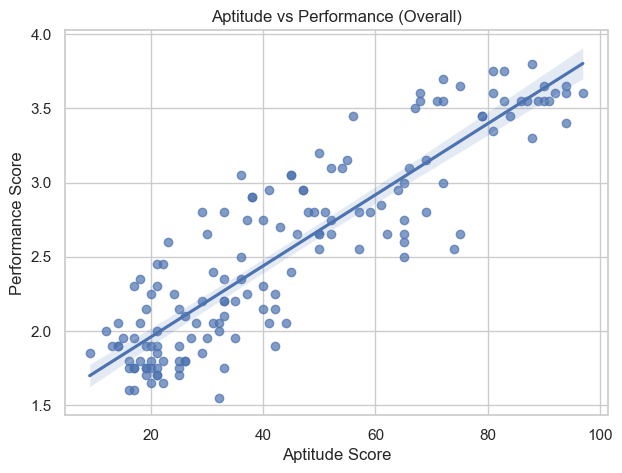

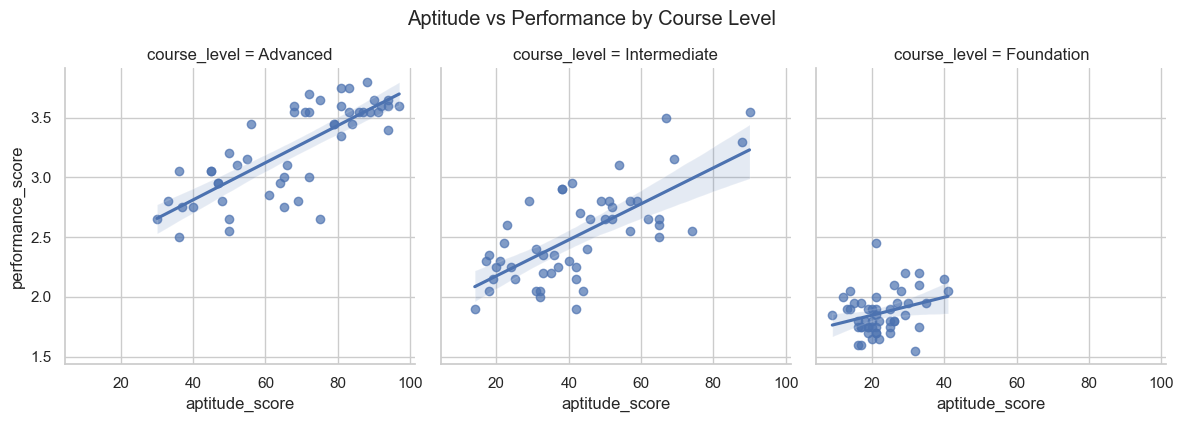

In [28]:

md("## 7.4 Visualization")

plt.figure(figsize=(7,5))
sns.regplot(data=df, x="aptitude_score", y="performance_score", scatter_kws={"alpha":0.7})
plt.title("Aptitude vs Performance (Overall)")
plt.xlabel("Aptitude Score")
plt.ylabel("Performance Score")
plt.show()

g = sns.lmplot(
    data=df, x="aptitude_score", y="performance_score",
    col="course_level", col_order=LEVEL_ORDER,
    height=4, aspect=1, scatter_kws={"alpha":0.7}
)
g.fig.suptitle("Aptitude vs Performance by Course Level", y=1.05)
plt.show()


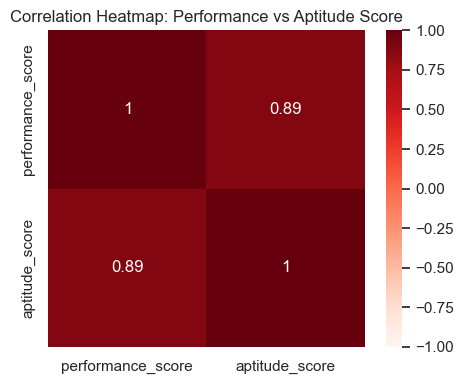

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# compute correlation matrix
corr_matrix = df[["performance_score", "aptitude_score"]].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Reds",
    vmin=-1,
    vmax=1,
    square=True
)
plt.title("Correlation Heatmap: Performance vs Aptitude Score")
plt.tight_layout()
plt.show()


# Chapter 8 — Effect Size and Practical Interpretation
## 8.1 Why Effect Size Matters
## 8.2 ANOVA Effect Size (η² / ω²)
## 8.3 Pairwise Effect Size (Cohen’s d)
## 8.4 Practical Interpretation Summary


In [30]:

def interpret_eta(eta: float) -> str:
    if eta < 0.01:
        return "negligible"
    elif eta < 0.06:
        return "small"
    elif eta < 0.14:
        return "medium"
    else:
        return "large"

def interpret_d(d: float) -> str:
    ad = abs(d)
    if ad < 0.20:
        return "negligible"
    elif ad < 0.50:
        return "small"
    elif ad < 0.80:
        return "medium"
    else:
        return "large"

def cohens_d(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / dof)
    return (x.mean() - y.mean()) / pooled_std


In [31]:

md("## 8.2 ANOVA Effect Size (η² / ω²)")

effects_anova = pd.DataFrame({
    "Measure": ["Eta Squared (η²)", "Omega Squared (ω²)"],
    "Performance Score": [eta_squared(anova_perf2), omega_squared(anova_perf2)],
    "Aptitude Score": [eta_squared(anova_apt2), omega_squared(anova_apt2)],
})
for col in ["Performance Score","Aptitude Score"]:
    effects_anova[col] = pd.to_numeric(effects_anova[col], errors="coerce")

display(effects_anova.style.format({"Performance Score":"{:.4f}", "Aptitude Score":"{:.4f}"}))

md(
    f"### Interpretation\n"
    f"- Performance η² = **{eta_squared(anova_perf2):.3f}** → **{interpret_eta(eta_squared(anova_perf2))}** effect  \n"
    f"- Aptitude η² = **{eta_squared(anova_apt2):.3f}** → **{interpret_eta(eta_squared(anova_apt2))}** effect"
)


## 8.2 ANOVA Effect Size (η² / ω²)

,Measure,Performance Score,Aptitude Score
0,Eta Squared (η²),0.7438,0.5792
1,Omega Squared (ω²),0.7391,0.5718


### Interpretation
- Performance η² = **0.744** → **large** effect  
- Aptitude η² = **0.579** → **large** effect

In [32]:

md("## 8.3 Pairwise Effect Size (Cohen’s d)")

pairs = [("Foundation","Intermediate"), ("Intermediate","Advanced"), ("Foundation","Advanced")]

rows = []
for a, b in pairs:
    d_perf = cohens_d(df[df["course_level"]==a]["performance_score"], df[df["course_level"]==b]["performance_score"])
    d_apt  = cohens_d(df[df["course_level"]==a]["aptitude_score"], df[df["course_level"]==b]["aptitude_score"])
    rows.append({
        "Comparison": f"{a} vs {b}",
        "Cohen_d_Performance": d_perf,
        "Interpretation_Performance": interpret_d(d_perf),
        "Cohen_d_Aptitude": d_apt,
        "Interpretation_Aptitude": interpret_d(d_apt),
    })

cohen_table = pd.DataFrame(rows)
display(cohen_table.style.format({"Cohen_d_Performance":"{:.3f}","Cohen_d_Aptitude":"{:.3f}"}))


## 8.3 Pairwise Effect Size (Cohen’s d)

,Comparison,Cohen_d_Performance,Interpretation_Performance,Cohen_d_Aptitude,Interpretation_Aptitude
0,Foundation vs Intermediate,-2.150,large,-1.460,large
1,Intermediate vs Advanced,-1.859,large,-1.320,large
2,Foundation vs Advanced,-4.596,large,-3.112,large


In [33]:

md("## 8.4 Practical Interpretation Summary")

md(
    f"### Summary of Practical Meaning\n"
    f"- **Group differences (ANOVA):**\n"
    f"  - Performance η² = **{eta_squared(anova_perf2):.3f}** (**{interpret_eta(eta_squared(anova_perf2))}**) \n"
    f"  - Aptitude η² = **{eta_squared(anova_apt2):.3f}** (**{interpret_eta(eta_squared(anova_apt2))}**) \n\n"
    f"- **Aptitude–Performance relationship (Correlation):**\n"
    f"  - Overall r = **{r_all:.3f}** (**{corr_strength(r_all)}**) → explained variance ≈ **{(r_all**2)*100:.1f}%**\n\n"
    f"**Conclusion:** Effect size results support that course levels are meaningfully distinct in practice, and aptitude is a practically relevant predictor of performance."
)


## 8.4 Practical Interpretation Summary

### Summary of Practical Meaning
- **Group differences (ANOVA):**
  - Performance η² = **0.744** (**large**) 
  - Aptitude η² = **0.579** (**large**) 

- **Aptitude–Performance relationship (Correlation):**
  - Overall r = **0.887** (**very strong**) → explained variance ≈ **78.8%**

**Conclusion:** Effect size results support that course levels are meaningfully distinct in practice, and aptitude is a practically relevant predictor of performance.